# EDA — Medical Appointment No Shows

Dataset: https://www.kaggle.com/datasets/joniarroba/noshowappointments


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Load dữ liệu


In [52]:
import kagglehub
from pathlib import Path

# https://www.kaggle.com/datasets/joniarroba/noshowappointments
path = kagglehub.dataset_download("joniarroba/noshowappointments")
csv_path = Path(path) / "KaggleV2-May-2016.csv"

data = pd.read_csv(csv_path)
print(csv_path)
data.head()

/Users/macintoshhd/.cache/kagglehub/datasets/joniarroba/noshowappointments/versions/5/KaggleV2-May-2016.csv


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## 2. Kiểm tra kích thước và kiểu dữ liệu

Bộ này thường có **110.527 dòng, 14 cột**. Target là `No-show` (`Yes` = vắng, `No` = đến khám).

- `ScheduledDay`, `AppointmentDay` đang là `object` → cần `pd.to_datetime`
- Một số tên cột viết sai chính tả trong data gốc: `Hipertension`, `Handcap`

In [53]:
print("số dòng, số cột:", data.shape)
print("tên cột:", data.columns.tolist())
data.info()

số dòng, số cột: (110527, 14)
tên cột: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_rec

### Đổi kiểu `object` sang `datetime`

`'A'` trong công thức mẫu là **tên cột**. 

Hai cách tương đương (bỏ giờ, chỉ giữ ngày):

```python
pd.to_datetime(data['A']).dt.normalize()
pd.to_datetime(data['A']).dt.date.astype('datetime64[ns]')
```

- `pd.to_datetime(...)` — chữ `'2016-04-29T18:38:08Z'` → datetime
- `.dt.normalize()` — đặt giờ về `00:00:00`
- `.dt.date.astype('datetime64[ns]')` — lấy ngày rồi đổi lại datetime


In [54]:
# converting data time to standard time cho ScheduledDay và AppointmentDay
# TODO CODE


In [55]:
data['ScheduledDay'] = pd.to_datetime(data['ScheduledDay']).dt.date.astype('datetime64[ms]')
data['AppointmentDay'] = pd.to_datetime(data['AppointmentDay']).dt.normalize()
data

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,0,0,0,0,0,1,No


create new column to analyse day of week
- gợi ý: dt.dayofweek

In [56]:
data['sch_weekday'] = data['ScheduledDay'].dt.dayofweek
data['app_weekday'] = data['AppointmentDay'].dt.dayofweek
data


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,sch_weekday,app_weekday
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,4,4
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,4,4
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,4,4
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,4,4
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,0,0,0,0,0,1,No,1,1
110523,3.596266e+12,5650093,F,2016-05-03,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,0,0,0,0,0,1,No,1,1
110524,1.557663e+13,5630692,F,2016-04-27,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,0,0,0,0,0,1,No,2,1
110525,9.213493e+13,5630323,F,2016-04-27,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,0,0,0,0,0,1,No,2,1


* value_count() cho data['app_weekday'] và data['sch_weekday']

In [57]:
data['sch_weekday'].value_counts()



sch_weekday
1    26168
2    24262
0    23085
4    18915
3    18073
5       24
Name: count, dtype: int64

In [58]:
data['app_weekday'].value_counts()

app_weekday
2    25867
1    25640
0    22715
4    19019
3    17247
5       39
Name: count, dtype: int64

dayofweek is a pandas's datatype to find the day of a week (0-mon, 3,4,5,6-sun). From above result, we can see that most of the scheduled and appointments are on weekdays than weekend

### Visualizing the results

`sns.countplot` — đếm số dòng từng nhóm (thứ trong tuần, `Gender`, `No-show`).

**So sánh các hàm plot hay dùng**

| Hàm | Dùng khi nào | Ví dụ |
|---|---|---|
| `countplot` | số **dòng** từng nhóm (biến phân loại) | `sns.countplot(x='No-show', data=data, palette='Set2')` |
| `histplot` | phân phối biến **số** | `sns.histplot(data['Age'], kde=True)` |
| `barplot` | **trung bình** (hoặc tổng) một cột số theo nhóm | `sns.barplot(x='Gender', y='Age', data=data)` |
| `boxplot` | min, Q1, median, Q3, outlier theo nhóm | `sns.boxplot(x='No-show', y='Age', data=data)` |
| `violinplot` | như boxplot **và** mật độ phân phối | `sns.violinplot(x='Gender', y='Age', data=data)` |

`countplot` ≈ `value_counts()` nhưng vẽ cột. `hue='No-show'` để tách màu theo nhóm.

<Axes: xlabel='sch_weekday', ylabel='count'>

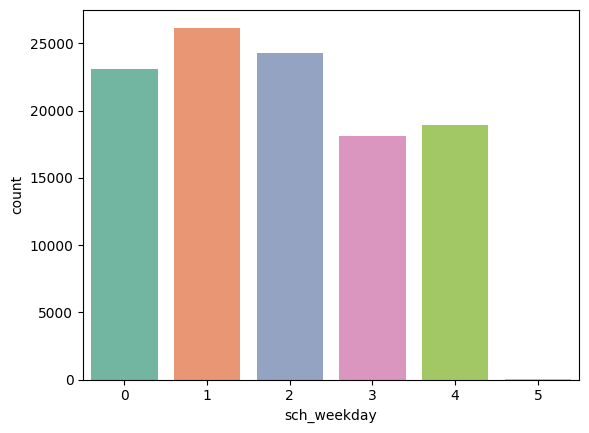

In [59]:
sns.countplot(x='sch_weekday', data=data, palette='Set2')


<Axes: xlabel='app_weekday', ylabel='count'>

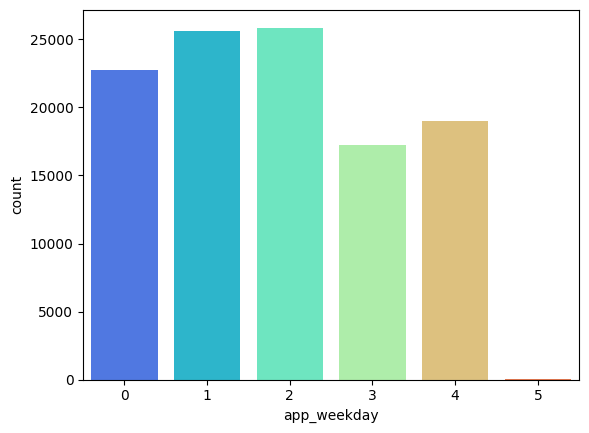

In [60]:
sns.countplot(x='app_weekday', data=data, palette='rainbow')



In [61]:
data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show',
       'sch_weekday', 'app_weekday'],
      dtype='object')

Correcting spelling mistakes of columns name

In [62]:
data = data.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap'})

In [63]:
data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No-show',
       'sch_weekday', 'app_weekday'],
      dtype='object')

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ms]     
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hypertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handicap        110527 non-null  int64              
 12  SMS_received    110527 non-null  int64              
 13  No-show       

In [65]:
# axis = 1 là cột, axis = 0 là dòng
data = data.drop(columns=['PatientId', 'AppointmentID', 'AppointmentDay', 'ScheduledDay'], axis=1)

In [66]:
data.columns

Index(['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No-show',
       'sch_weekday', 'app_weekday'],
      dtype='object')

returning values for aggregate functions using describe() function

In [67]:
data.describe()

# std độ rộng, độ hẹp của phân bố

,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,sch_weekday,app_weekday
count,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,1.851955,1.858243
std,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,1.378520,1.371672
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,3.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,5.000000,5.000000


In [68]:
# số lượng theo từng nhóm
data['No-show'].value_counts()

No-show
No     88208
Yes    22319
Name: count, dtype: int64

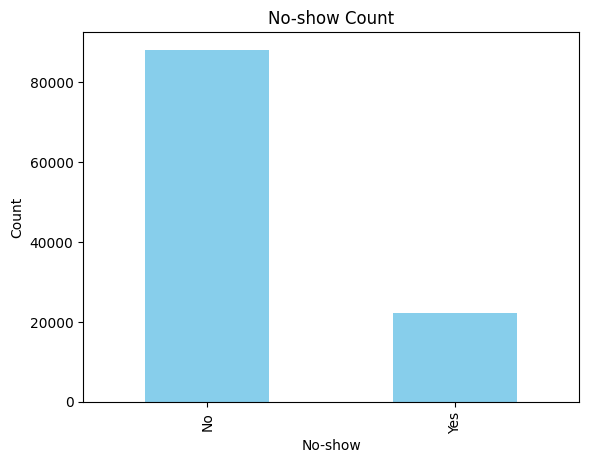

In [69]:
data['No-show'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('No-show')
plt.ylabel('Count')
plt.title('No-show Count')
plt.show()




Calculating the percentage of appointment or not

In [70]:
100*data['No-show'].value_counts()/len(data)

No-show
No     79.806744
Yes    20.193256
Name: count, dtype: float64

So infer that approximatelu 80% of appointment says no

Having a look that data contains missing values or not

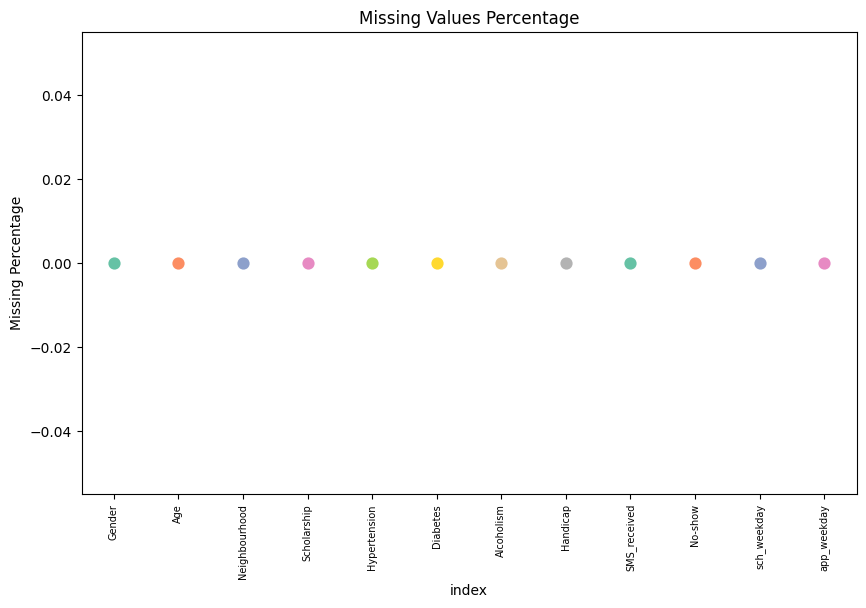

In [79]:
missing=pd.DataFrame((data.isnull().sum())*100/data.shape[0]).reset_index()

plt.figure(figsize=(10,6))
ax = sns.pointplot(x='index', y=0, data=missing, palette='Set2')
plt.xticks (rotation=90, fontsize=7)
plt.ylabel('Missing Percentage')
plt.title('Missing Values Percentage')
plt.show()








Missing data - intital Intution
Here we don't have any missing data
for features with less missing data, we can use regression to predict the missing values or fill with the mean of the values present, depending on the features.

For features with very high number of missing values it is better to drop those columns as they give very less insight on analysts

ìf we have more than 30-40% of missing values, deleting those might be effective.

There is no need of DATA CLEANING since there is no NULL values

In [80]:
data['Age'].max()

115

grouping the tenure in bins of 12 months

In [81]:
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72', '73-84', '85-96', '97-108', '109-120']
data['Age_group'] = pd.cut(data['Age'], bins=range(0, 121, 12), labels=labels, right=False)
data['Age_group'].value_counts()





Age_group
0-12       19944
49-60      18914
37-48      17436
25-36      16978
13-24      16081
61-72      13295
73-84       6132
85-96       1700
97-108        41
109-120        5
Name: count, dtype: int64

Having a look info the values of count of each columns and there count in respect to Noshow columns

---------- Gender ----------
Gender
F    71840
M    38687
Name: count, dtype: int64


---------- Age ----------
Age
 0      3539
 1      2273
 52     1746
 49     1652
 53     1651
        ... 
 115       5
 100       4
 102       2
 99        1
-1         1
Name: count, Length: 104, dtype: int64


---------- Neighbourhood ----------
Neighbourhood
JARDIM CAMBURI                 7717
MARIA ORTIZ                    5805
RESISTÊNCIA                    4431
JARDIM DA PENHA                3877
ITARARÉ                        3514
                               ... 
ILHA DO BOI                      35
ILHA DO FRADE                    10
AEROPORTO                         8
ILHAS OCEÂNICAS DE TRINDADE       2
PARQUE INDUSTRIAL                 1
Name: count, Length: 81, dtype: int64


---------- Scholarship ----------
Scholarship
0    99666
1    10861
Name: count, dtype: int64


---------- Hypertension ----------
Hypertension
0    88726
1    21801
Name: count, dtype: int64


---------- Diabetes 

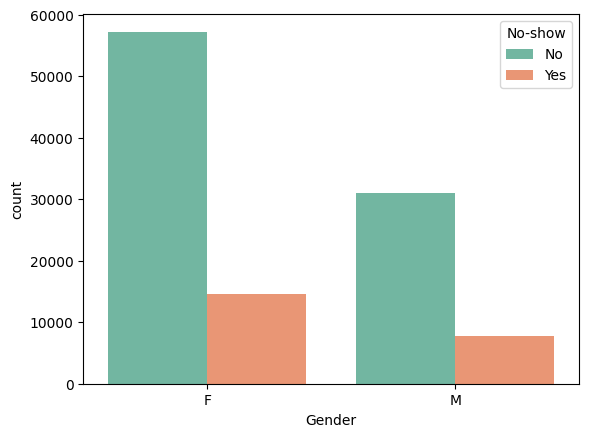

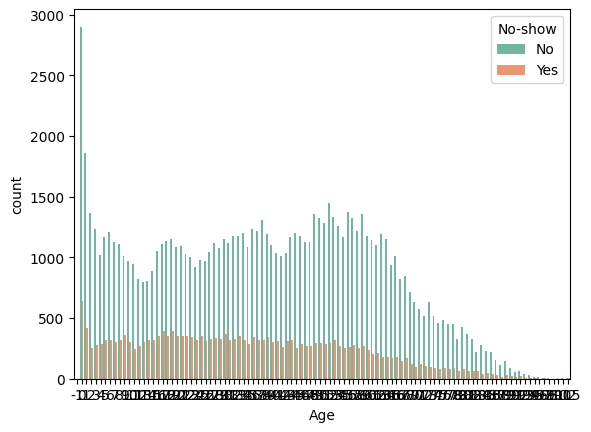

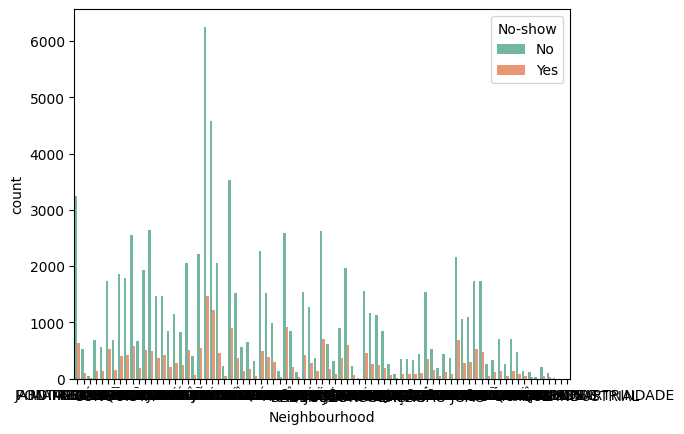

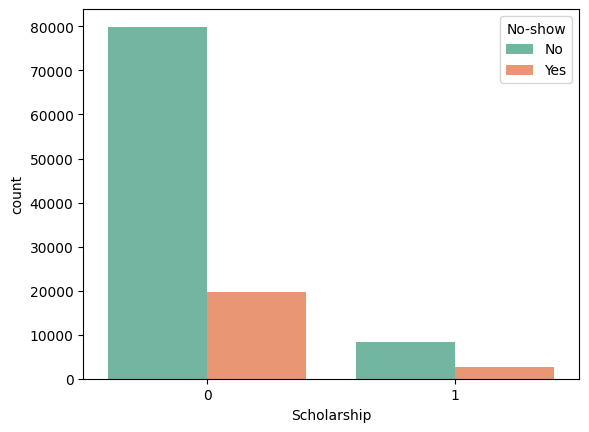

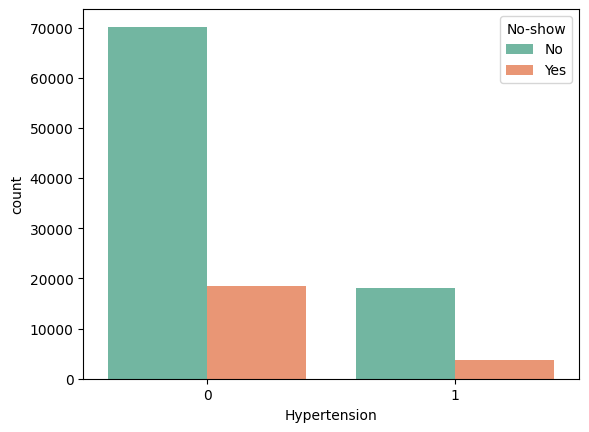

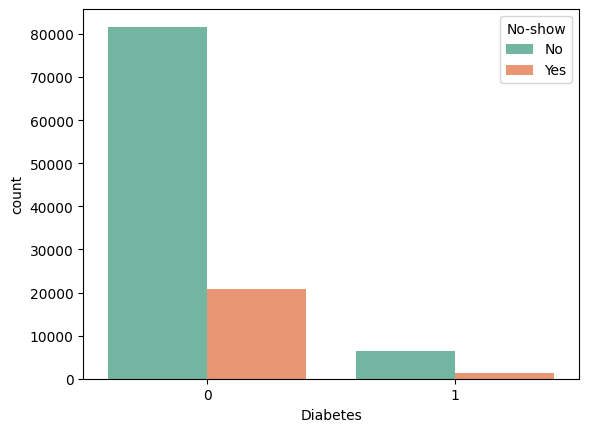

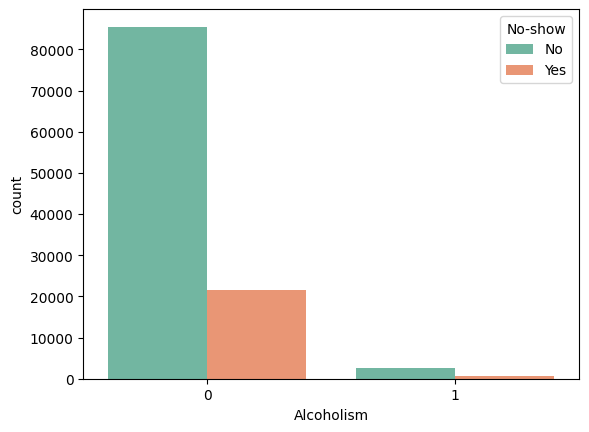

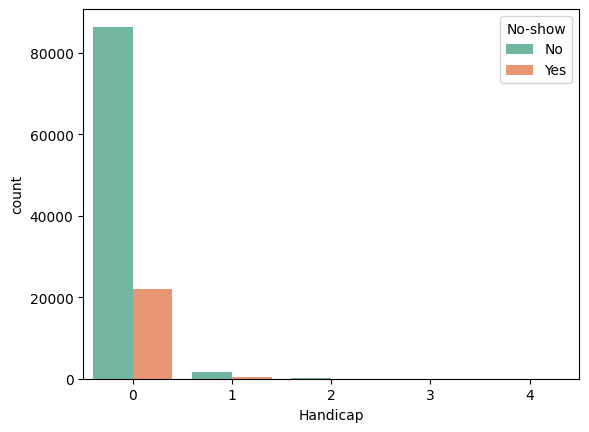

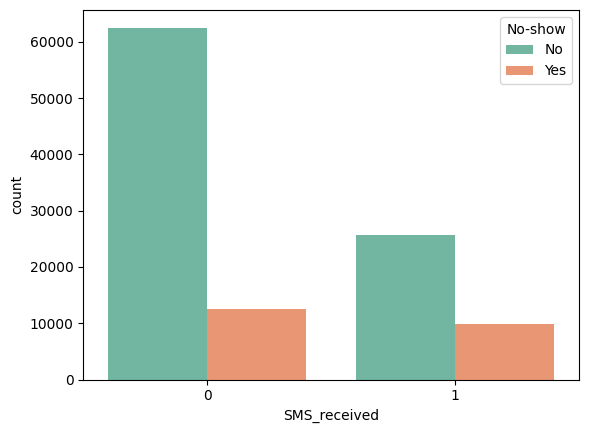

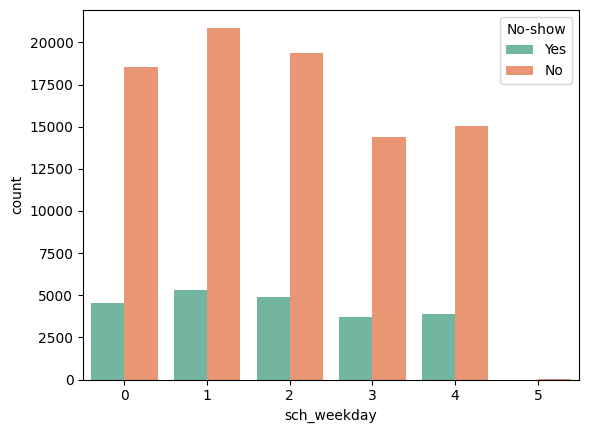

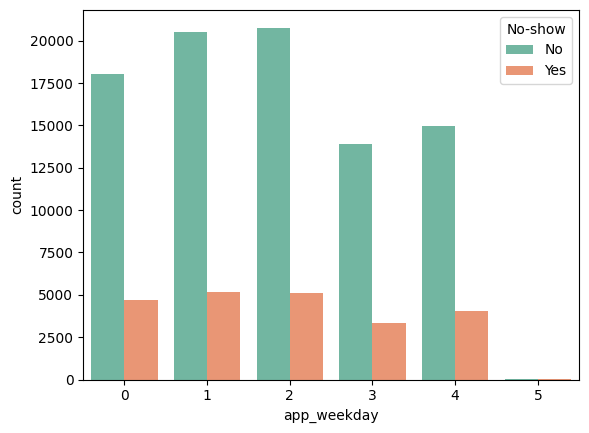

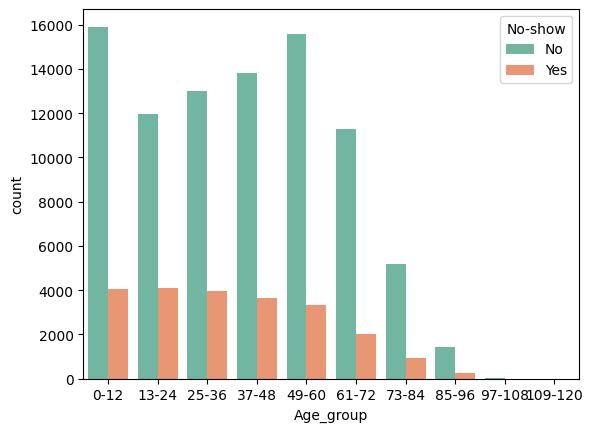

In [83]:
for i, predictor in enumerate(data.drop(columns=['No-show'])):
    print('-'*10, predictor,"-"*10)
    print(data[predictor].value_counts())
    plt.figure(i)
    sns.countplot(data=data, x= predictor, hue='No-show', palette='Set2')
    print("\n")






changing NO as 0 and Yes as 1

In [93]:
data['No-show'] = np.where(data['No-show'] == 'Yes', 1, 0)
data['No-show'].value_counts()






No-show
0    110527
Name: count, dtype: int64

convert all the categorical variables into dummy variables

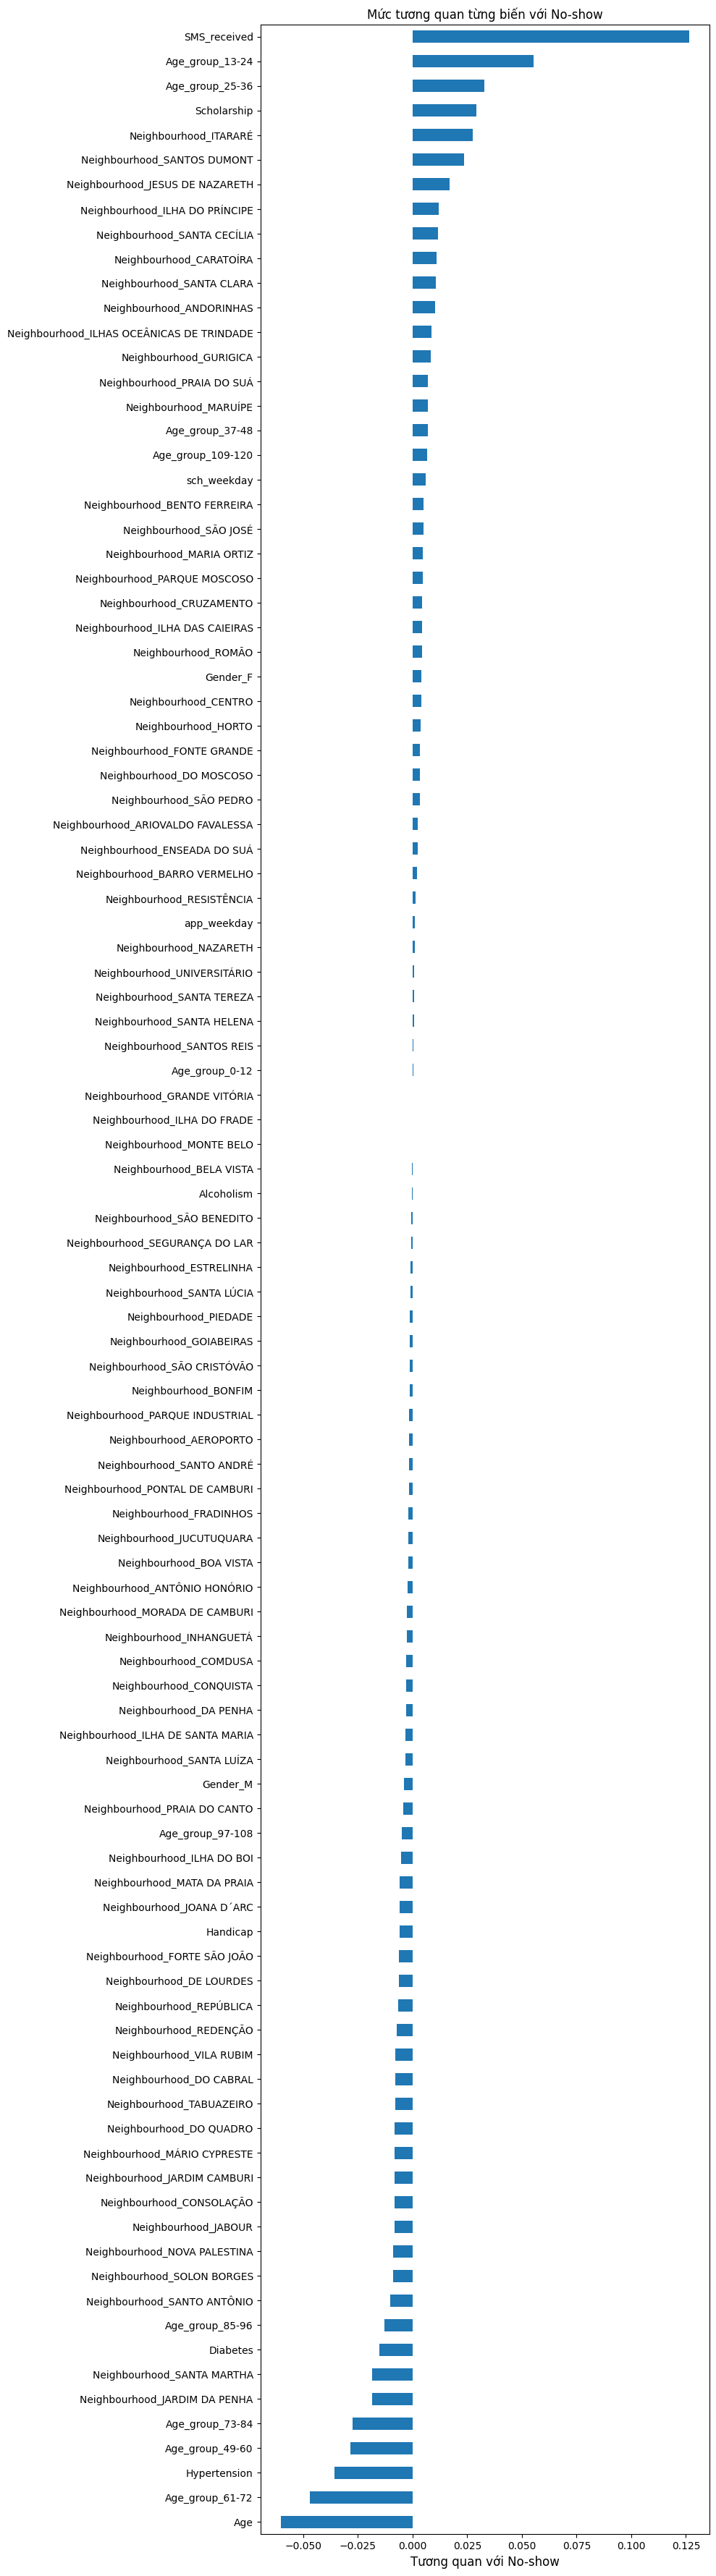

In [94]:
corr_noshow = data.dummies.corr(numeric_only=True)['No-show'].drop('No-show').sort_values()

plt.figure(figsize=(10, max(8, 0.35 * len(corr_noshow))))
corr_noshow.plot(kind='barh')
plt.xlabel('Tương quan với No-show', fontsize=12)
plt.ylabel('')
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.title('Mức tương quan từng biến với No-show')
plt.tight_layout()
plt.show()



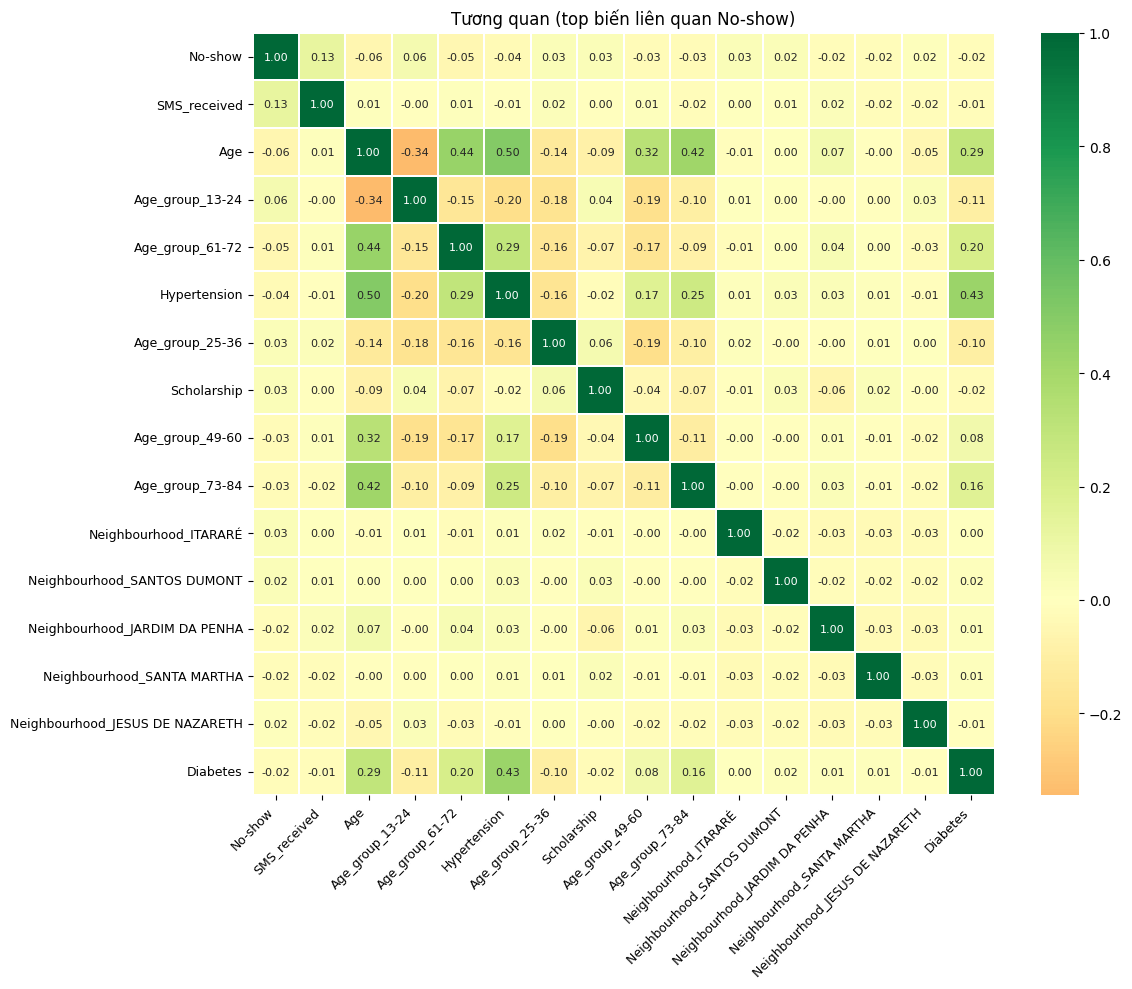

In [96]:
corr = data.dummies.corr(numeric_only=True)
# Chỉ lấy ~15 biến tương quan mạnh nhất với No-show — heatmap đủ cột sẽ chồng chữ
top = corr['No-show'].abs().sort_values(ascending=False).head(16).index
corr_top = corr.loc[top, top]

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_top,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.3,
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title('Tương quan (top biến liên quan No-show)')
plt.tight_layout()
plt.show()

## 7. Kết luận (Insights)

Đây là **kết luận mô tả** từ EDA — data cho thấy gì. Chưa chứng minh nhân quả, chưa phải mô hình dự đoán.

1. **Giới tính:** Nữ đặt lịch nhiều hơn nam.
2. **Tuổi:** Hầu hết nhóm tuổi có tỷ lệ đến khám gần nhau (~80%). Nhóm tuổi 0 và 1 cũng khoảng 80% đến.
3. **Quận (Neighbourhood):** Mỗi khu vực đều khoảng 80% bệnh nhân đến khám — khác biệt giữa các quận không lớn.
4. **Scholarship:** Khoảng 99.666 người không có hỗ trợ, ~80% đến khám. Khoảng 21.801 người có hỗ trợ, ~75% đến — thấp hơn một chút.
5. **Tăng huyết áp:** Không bệnh ~88.726 người, ~78% đến. Có bệnh ~21.801 người, ~85% đến — nhóm này đến đều hơn.
6. **Tiểu đường:** Không bệnh ~102.584 người, ~80% đến. Có bệnh ~7.943 người, ~83% đến — chênh nhẹ.
7. **SMS:** Không nhận SMS ~75.045 người, ~84% đến. Có nhận SMS ~35.482 người, ~72% đến. **Có SMS lại vắng nhiều hơn** — thường vì SMS gửi cho lịch đặt sớm / nhóm rủi ro, không chắc SMS làm người ta vắng.
8. **Thứ trong tuần:** Không có lịch Chủ nhật. Thứ 7 rất ít so với các ngày trong tuần.

**Tóm lại:** Phần lớn bệnh nhân **đến khám (~80%)**. Các yếu tố địa phương, tuổi, bệnh nền chênh không nhiều. Đáng chú ý: **scholarship** và **SMS** đi kèm tỷ lệ đến thấp hơn một chút; cuối tuần gần như không có lịch.
